In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time as time_package
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.linalg import inv
from scipy.special import logsumexp
from multiprocessing import Pool

from research_code import *

np.random.seed(0)

data_dir = os.path.join(project_root,'data')
fig_dir = os.path.join(data_dir,'figures')

labels = ['UKF-UI','HKF-ndm','HKFS-ndm','HKF','HKFS',]
colors = ['#181','#a55','#a11','#55a','#11a']
highlight_color = '#fdf2d0a0'

example_name = 'impact'

In [2]:
import matplotlib as mpl

MM_TO_INCH = 1/25.4

TEXTWIDTH_MM = 164.6
FIG_W = TEXTWIDTH_MM * MM_TO_INCH
FIG_H = 25 * MM_TO_INCH
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.grid.which": "major",
    "axes.axisbelow": True,


    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,

    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",

    'lines.linewidth': 0.6,
    'hatch.linewidth': 0.6,

    "font.family": "serif", 
    "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7.5,

    "figure.figsize": (FIG_W, FIG_H),

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "mathtext.fontset": "stix",
})

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)
plt.rcParams['axes.unicode_minus'] = False

mpl.rcParams['figure.dpi'] = 150

In [3]:
mass = [500]
damping = [0.05]
stiff = [4e4]
comp_mat = np.eye(1)

param = BilinearParameter(fy = [2e3], alpha = [0.1])

system = BilinearSystem(
    mass = mass,
    damping = damping,
    stiff = stiff, 
    parameter = param,
    comp_mat = comp_mat,
    )

In [4]:
time = Time(start = 0, end = 10, interval = 0.001)
force_value = np.zeros(time.value.shape)
force_value[2000:2050] = 8000*np.linspace(0,1,50)
force_value[2050:2100] = 8000*np.linspace(1,0,50)
force = Force.assign_by_value(time_point = time.value, value = force_value)

response = compute_response(
    system = system,
    force = force,
    time = time,
    ctype = 'Newmark',
    )

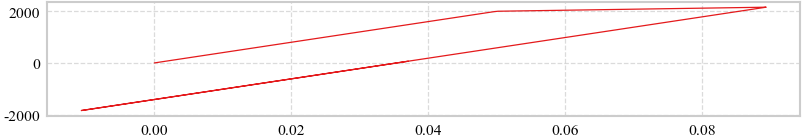

In [5]:
f=0
plt.plot(response.element_disp[f], response.resisting_force[f])

In [6]:
time,force,response = slice_data(time,force,response,0.01)

SNR_dB = 15
std_noise = (np.var(response.acc) / (10**(SNR_dB/10)))**0.5
print(std_noise)
measurement = add_noise(response.acc,std_noise)
measurement_dm = np.vstack((measurement,np.zeros((system.force_dim,time.length)),np.zeros((system.force_dim,time.length))))


noise = measurement - response.acc
snr_db = 10*np.log10(np.var(response.acc) / np.var(noise))

snr_db_rms = 20*np.log10(np.sqrt(np.mean(response.acc**2)) /
                         np.sqrt(np.mean(noise**2)))


0.2559855435401642


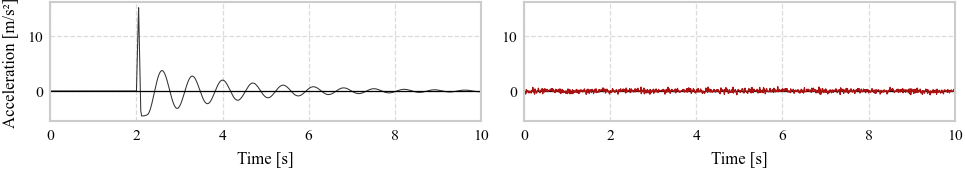

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H*1.2), constrained_layout=True, sharey=True)
ax1.axhline(0, color='k')
ax1.plot(time.value, response.acc[0,:], color='k', alpha=0.8, lw=0.5)
ax1.set_ylabel('Acceleration [m/s²]')
ax1.set_xlim([0,10])
ax1.set_xlabel('Time [s]')

ax2.tick_params(axis='y', left=True, labelleft=True)
ax2.axhline(0, color='k')
ax2.plot(time.value, response.acc[0,:]-measurement[0,:], color=colors[2])
ax2.set_xlim([0,10])
ax2.set_xlabel('Time [s]')

plt.savefig(os.path.join(fig_dir,'measurement_'+example_name+'.pdf'))

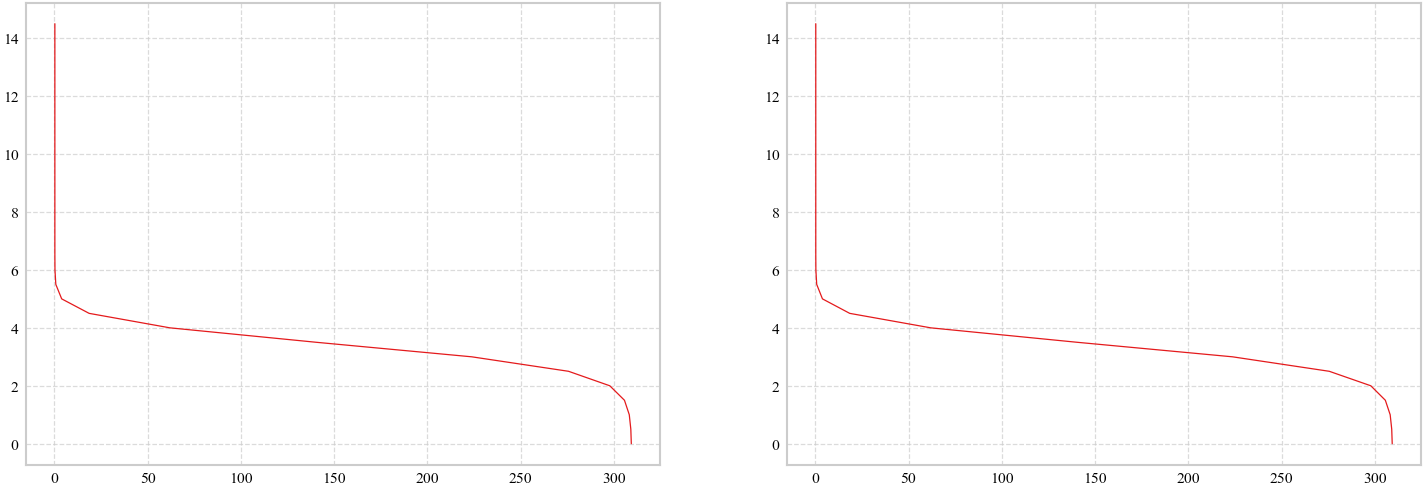

In [8]:
ssm = HysteresisSSM(system, time)
ssm_dm = HysteresisDMSSM5(system, time)

cov_model = [1e-6]*(2*system.dim+system.element_dim)

cov_measurement = np.diag([std_noise**2]*system.dim)
cov_measurement_dm = np.diag([std_noise**2]*system.dim+[10**-2]*system.element_dim+[10**10]*system.force_dim)
cov_force = [10**0]*system.force_dim

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm, cov_force=cov_force)

force_cov_list1 = np.arange(0,15,0.5)
force_cov_list2 = np.arange(0,15,0.5)

err = ssm.draw_Lcurve(measurement = measurement, initial_state_cov = np.eye(ssm.state_size)*10**-10, force_cov_list=force_cov_list1, num_cores = 32)
err_dm = ssm_dm.draw_Lcurve(measurement = measurement_dm, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10, force_cov_list=force_cov_list2, num_cores = 32)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(err[:,0], force_cov_list1)
plt.subplot(1,2,2)
plt.plot(err_dm[:,0], force_cov_list2)
plt.show()

In [9]:
ssm = HysteresisSSM(system, time)
ssm_dm = HysteresisDMSSM5(system, time)

cov_force = [10**5.5]*system.force_dim
cov_force5 = [10**5.5]*system.force_dim

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm, cov_force=cov_force5)

response_kf, force_kf, response_rts, force_rts = ssm.kfrts(measurement, initial_state_cov = np.eye(ssm.state_size)*10**-6)
response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm = ssm_dm.kfrts(measurement_dm, initial_state_cov = np.eye(ssm_dm.state_size)*10**-6)

In [10]:
def UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement, alpha):
    state_dim = system.dim * 2 + system.element_dim
    force_dim = system.force_dim

    est_state = np.zeros((state_dim, time.length))
    est_cov = np.zeros((state_dim, state_dim, time.length))
    est_force = np.zeros((force_dim, time.length))

    state = initial_state
    cov = initial_cov
    force = np.zeros(force_dim)
    acc = compute_acc(system, state, force)

    beta = 2.0
    kappa = 0.0

    n = state_dim
    lam = alpha**2 * (n) - n
    c = n + lam

    Wm = np.full(2*n + 1, 1.0/(2*c))
    Wc = np.full(2*n + 1, 1.0/(2*c))
    Wm[0] = lam / c
    Wc[0] = lam / c + (1 - alpha**2 + beta)

    for ii in range(time.length):
        if ii % 10 == 0:
            print(f"Progress: {ii}/{time.length}", end='\r')
        evalues, evectors = np.linalg.eig(cov)
        assert (evalues >= 0).all()
        sigma_points = np.zeros((state_dim, 2*state_dim + 1))
        sigma_points[:,0] = state
        L = np.linalg.cholesky(cov)
        for j in range(n):
            sigma_points[:, j+1]     = state + np.sqrt(c) * L[:, j]
            sigma_points[:, j+1+n]   = state - np.sqrt(c) * L[:, j]
        state_pred_points, acc_pred_points = compute_response_step(system, time, sigma_points, force, acc)
        state_pred = np.sum(Wm * state_pred_points, axis=1)
        diff = state_pred_points - state_pred[:, None]
        cov_pred = diff @ np.diag(Wc) @ diff.T + model_cov
        
        Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
        Cc2 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag((1-system.alpha)*system.element_stiff))
        Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
        Cc4 = np.atleast_2d(inv(system.mass)@system.force_influence)
        Cc = np.hstack((Cc1, Cc2, Cc3))

        force = inv(Cc4.T@Cc4)@(Cc4.T)@(measurement[:,ii] - Cc @ state_pred)

        meas_pred_points = compute_acc(system, state_pred_points, force)
        meas_pred = np.sum(Wm * meas_pred_points, axis=1)
        meas_diff = meas_pred_points - meas_pred[:, None]
        cov_meas = meas_diff @ np.diag(Wc) @ meas_diff.T + measurement_cov

        cross_diff = state_pred_points - state_pred[:, None]
        cross_cov = cross_diff @ np.diag(Wc) @ meas_diff.T
        K = cross_cov @ np.linalg.inv(cov_meas)

        state = state_pred + K @ (measurement[:,ii] - meas_pred)
        cov = cov_pred - K @ cov_meas @ K.T
        
        acc = compute_acc(system, state, force)

        est_state[:,ii] = state
        est_cov[:,:,ii] = cov
        est_force[:,ii] = force

    return est_state, est_cov, est_force

def compute_response_step(system,time,state_list,force,acc):
    state_post = np.zeros(state_list.shape)
    acc_post = np.zeros((system.dim,state_list.shape[1]))
    for ii in range(state_list.shape[1]):
        state = state_list[:,ii]

        GAMMA = 1/2
        BETA = 1/4

        A1 = 1/BETA/time.interval**2*system.mass + GAMMA/BETA/time.interval*system.damping
        A2 = 1/BETA/time.interval*system.mass + (GAMMA/BETA-1)*system.damping
        A3 = (1/2/BETA-1)*system.mass + system.damping*time.interval*(GAMMA/2/BETA-1)

        tangent_stiff_hat = system.stiff + A1
        tangent_stiff_hat_inv = inv(tangent_stiff_hat)

        MAX_ITER = 5000
        disp = state[0:system.dim].copy()
        aux = state[system.dim:system.dim+system.element_dim].copy()
        element_disp = system.comp_mat @ disp
        resisting_force = system.alpha*system.element_stiff*element_disp+(1-system.alpha)*system.element_stiff*aux
        force_hat = system.force_influence@force + A1@disp + A2 @ state[system.dim+system.element_dim:system.dim*2+system.element_dim] + A3 @ acc
        for jj in range(MAX_ITER):
            residual_force = force_hat - system.comp_mat.T @ resisting_force - A1 @ disp
            delta_disp = tangent_stiff_hat_inv @ residual_force
            disp += delta_disp
            element_disp = system.comp_mat @ disp
            delta_element_disp = element_disp - system.comp_mat @ state[0:system.dim]

            if system.model == 'BoucWen':
                delta_aux = delta_element_disp*(system.A-abs(state[system.dim:system.dim+system.element_dim])**system.n*(system.gamma+system.beta*np.sign(state[system.dim:system.dim+system.element_dim]*(system.comp_mat@state[system.dim+system.element_dim:system.dim*2+system.element_dim]))))
                aux = state[system.dim:system.dim+system.element_dim] + delta_aux
                resisting_force = system.alpha*system.element_stiff*element_disp+(1-system.alpha)*system.element_stiff*aux
            
            if (np.all(residual_force**2 < 1e-12) or
                np.all(residual_force**2 / np.maximum(np.max(np.abs(force_hat)), 1e-10)**2 < 1e-12)):
                break

        if jj == MAX_ITER-1 and np.any(np.abs(residual_force) >= 1e-10):
            print(residual_force, force_hat)
            print('Newton-Raphson did not converge')                    

        vel = GAMMA/BETA/time.interval*(disp-state[0:system.dim])+(1-GAMMA/BETA)*state[system.dim+system.element_dim:system.dim*2+system.element_dim]+time.interval*(1-GAMMA/2/BETA)*acc
        state_post[:,ii] = np.concatenate((disp, aux, vel))
        acc_post[:,ii] = compute_acc(system, state_post[:,ii], force)

    return state_post, acc_post

def compute_acc(system, state, force):
    Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
    Cc2 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag((1-system.alpha)*system.element_stiff))
    Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
    Cc4 = np.atleast_2d(inv(system.mass)@system.force_influence)
    Cc = np.hstack((Cc1, Cc2, Cc3))
    return Cc@state + Cc4@force

In [11]:
initial_state = np.zeros(system.dim*2+system.element_dim)
initial_cov = np.eye(system.dim*2+system.element_dim)*1e-10
model_cov = np.diag([1e-6]*(system.dim*2+system.element_dim))
measurement_cov = np.diag([std_noise**2]*system.dim)
scale = 1.0

est_state, est_cov, est_force = UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement, scale)

In [12]:
def rmse(true, pred):
    return np.sqrt(np.mean((true-pred)**2,axis=1))

rmse_kf_disp = rmse(response.disp, response_kf.disp)
rmse_kf_disp_dm = rmse(response.disp, response_kf_dm.disp)


rmse_kf_vel = rmse(response.vel, response_kf.vel)
rmse_kf_vel_dm = rmse(response.vel, response_kf_dm.vel)

rmse_kf_force = rmse(force.value, force_kf.value)
rmse_kf_force_dm = rmse(force.value, force_kf_dm.value)

rmse_rts_disp = rmse(response.disp, response_rts.disp)
rmse_rts_disp_dm = rmse(response.disp, response_rts_dm.disp)
rmse_ukf_disp = rmse(response.disp, est_state[0,:])


rmse_rts_vel = rmse(response.vel, response_rts.vel)
rmse_rts_vel_dm = rmse(response.vel, response_rts_dm.vel)
rmse_ukf_vel = rmse(response.vel, est_state[2,:])

rmse_rts_force = rmse(force.value, force_rts.value)
rmse_rts_force_dm = rmse(force.value, force_rts_dm.value)
rmse_ukf_force = rmse(force.value, est_force)

s = 190
e = 300
    
rows = [
    dict(name="Excitation [kN]",
         true_full=(force.value/1000)[0, :],      pred_list_full=[(est_force/1000)[0,:], (force_kf.value/1000)[0,:], (force_rts.value/1000)[0,:], (force_kf_dm.value/1000)[0,:], (force_rts_dm.value/1000)[0,:]],
         true_zoom=(force.value/1000)[0, s:e],    pred_list_zoom=[(est_force/1000)[0,s:e], (force_kf.value/1000)[0,s:e], (force_rts.value/1000)[0,s:e], (force_kf_dm.value/1000)[0,s:e], (force_rts_dm.value/1000)[0,s:e]],
         rmse_vals=[rmse_ukf_force[0], rmse_kf_force[0], rmse_rts_force[0], rmse_kf_force_dm[0], rmse_rts_force_dm[0]],
         ylim_zoom=(-1, 9)),
    dict(name="Displacement [m]",
         true_full=response.disp[f,:],     pred_list_full=[est_state[f,:], response_kf.disp[f,:], response_rts.disp[f,:], response_kf_dm.disp[f,:], response_rts_dm.disp[f,:]],
         true_zoom=response.disp[f,s:e],   pred_list_zoom=[est_state[f,s:e], response_kf.disp[f,s:e], response_rts.disp[f,s:e], response_kf_dm.disp[f,s:e], response_rts_dm.disp[f,s:e]],
         rmse_vals=[rmse_ukf_disp[0], rmse_kf_disp[0], rmse_rts_disp[0], rmse_kf_disp_dm[0], rmse_rts_disp_dm[0]],
         ylim_zoom=(-0.05, 0.15)),
    dict(name="Velocity [m/s]",
         true_full=response.vel[f,:],      pred_list_full=[est_state[f+2,:], response_kf.vel[f,:], response_rts.vel[f,:], response_kf_dm.vel[f,:], response_rts_dm.vel[f,:]],
         true_zoom=response.vel[f,s:e],    pred_list_zoom=[est_state[f+2,s:e], response_kf.vel[f,s:e], response_rts.vel[f,s:e], response_kf_dm.vel[f,s:e], response_rts_dm.vel[f,s:e]],
         rmse_vals=[rmse_ukf_vel[0], rmse_kf_vel[0], rmse_rts_vel[0], rmse_kf_vel_dm[0], rmse_rts_vel_dm[0]],
         ylim_zoom=None),
]


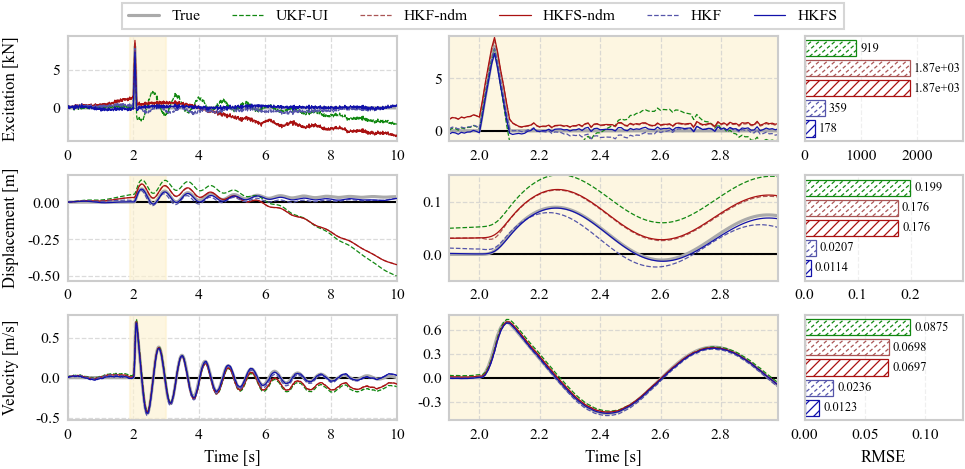

In [13]:
t_start = float(time.value[s])
t_end   = float(time.value[e-1])

num_col = 3

fig = plt.figure(figsize=(FIG_W, num_col*FIG_H), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=3, width_ratios=[2.5, 2.5, 1.2])

axes = []
linestyles = ['--', '--', '-', '--', '-'] 
hatches = ['dashed_slash', 'dashed_slash', '/////', 'dashed_slash', '/////']

def add_dashed_slash_fill(ax, patch, color, spacing=0.05, angle_deg =45):
    x0, y0 = patch.get_x(), patch.get_y()
    x1, y1 = x0 + patch.get_width(), y0 + patch.get_height()
    (xa0, ya0) = ax.transAxes.inverted().transform(ax.transData.transform((x0, y0)))
    (xa1, ya1) = ax.transAxes.inverted().transform(ax.transData.transform((x1, y1)))
    xa_min, xa_max = min(xa0, xa1), max(xa0, xa1)
    ya_min, ya_max = min(ya0, ya1), max(ya0, ya1)
    w_ax, h_ax = xa_max - xa_min, ya_max - ya_min
    if w_ax <= 0 or h_ax <= 0:
        return

    theta = np.deg2rad(angle_deg)
    bbox = ax.get_window_extent()
    w_px, h_px = bbox.width, bbox.height
    dx = h_ax * (h_px / (w_px * np.tan(theta)))

    offsets = np.arange(-dx, w_ax + spacing, spacing)
    for off in offsets:
        x_line = [xa_min + off, xa_min + off + dx]
        y_line = [ya_min, ya_max]
        (line,) = ax.plot(
            x_line, y_line,
            transform=ax.transAxes,
            color=color,
            linewidth=0.6,
            linestyle=(0, (3, 2)),
            solid_capstyle='butt',
            zorder=patch.get_zorder() + 0.1,
        )
        line.set_clip_path(patch)

for i in range(3):
    ax_full = fig.add_subplot(gs[i, 0])
    ax_zoom = fig.add_subplot(gs[i, 1])
    ax_rmse = fig.add_subplot(gs[i, 2])
    axes.append((ax_full, ax_zoom, ax_rmse))


for i, row in enumerate(rows):
    ax_full, ax_zoom, ax_rmse = axes[i]

    ax_full.axhline(0, color='k', lw=1)
    ax_full.axvspan(t_start, t_end, color=highlight_color)
    
    ax_full.plot(time.value, row["true_full"], color='#aaa', label='True', lw=1.5, zorder=2)
    for yhat, lab, col, ls in zip(row["pred_list_full"], labels, colors, linestyles):
        ax_full.plot(time.value, yhat, label=lab, color=col, ls=ls, zorder=3)
    ax_full.set_ylabel(row["name"])
    ax_full.set_xlim(0, 10)

    ax_zoom.set_facecolor(highlight_color)
    ax_zoom.axhline(0, color='k', lw=1)
    ax_zoom.plot(time.value[s:e], row["true_zoom"], color='#aaa', label='True', lw=1.5)
    for yhat, lab, col, ls in zip(row["pred_list_zoom"], labels, colors, linestyles):
        ax_zoom.plot(time.value[s:e], yhat, color=col, ls=ls)
    ax_zoom.set_xlim(t_start, t_end)
    if row["ylim_zoom"] is not None:
        ax_zoom.set_ylim(*row["ylim_zoom"])

    if i == 2:
        ax_rmse.set_xlabel("RMSE")
    
    bars = ax_rmse.barh(labels, row["rmse_vals"], color='#fff',edgecolor='k', linewidth=0.6)
    mx = max(row["rmse_vals"]) if len(row["rmse_vals"]) > 0 else 1
    ax_rmse.set_xlim(0, mx * 1.5)
    ax_rmse.invert_yaxis()
    for b, h, ec in zip(bars, hatches, colors):
        b.set_edgecolor(ec)
        if h == 'dashed_slash':
            add_dashed_slash_fill(ax_rmse, b, ec)
        else:
            b.set_hatch(h)

    ax_rmse.bar_label(bars, fmt="%.3g", padding=2, fontsize=6)
    ax_rmse.grid(True, axis='x', alpha=0.3, linestyle='--')
    ax_rmse.set_yticks([])

axes[-1][0].set_xlabel("Time [s]")
axes[-1][1].set_xlabel("Time [s]")

axes[-1][1].set_yticks([-0.3,0,0.3, 0.6])

handles, leg_labels = axes[0][0].get_legend_handles_labels()

fig.legend(
    handles, leg_labels,
    loc="center",
    bbox_to_anchor=(0.5, 1.03),
    frameon=True,
    fancybox=False,
    ncol=7
)
fig.align_ylabels([a[0] for a in axes])
plt.savefig(os.path.join(fig_dir, f"estimation_rmse_{example_name}.pdf"))